# Step 03 — Feature Engineering, Vectorization & Classical Modeling

## Objectif de ce notebook

Dans les étapes précédentes, nous avons construit un dataset nettoyé à partir de l’EDA :

- **Step 01** : compréhension du dataset et identification des anomalies.
- **Step 02** : nettoyage guidé par les anomalies détectées : Unicode, emojis, URLs, hashtags, mentions, slang, ponctuation, répétitions, doublons, textes vides, etc.


L’objectif est de comparer des approches classiques et solides :

1. séparation Train / Validation / Test ;
2. encodage des labels ;
3. vectorisation TF-IDF ;
4. analyse des matrices TF-IDF ;
5. entraînement de plusieurs modèles ;
6. gestion du déséquilibre des classes ;
7. vectorisation Word2Vec ;
8. comparaison TF-IDF vs Word2Vec ;
9. sélection du meilleur modèle à déployer.

> Principe important : toutes les vectorisations doivent être apprises uniquement sur le train set 

## 0. Installation optionnelle des librairies

Exécuter ces installations seulement si certaines librairies ne sont pas encore installées.

In [9]:
!pip install gensim
!pip install xgboost
!pip install joblib

## 1. Initialisation

Cette cellule regroupe toutes les librairies nécessaires pour l’étape 03.

On utilise principalement :
- `scikit-learn` pour la vectorisation TF-IDF, le split, les modèles classiques et les métriques ;
- `gensim` pour Word2Vec ;
- `joblib` pour sauvegarder le meilleur modèle.

In [11]:
import os
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, TransformerMixin

import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Chargement du dataset nettoyé


```text
mental_health_cleaned.csv
```

Il doit contenir au minimum :
- une colonne texte nettoyé : `clean_text`
- une colonne label : `status`



In [12]:
DATA_PATH = "mental_health_cleaned.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Le fichier mental_health_cleaned.csv est introuvable. "
        "Veuillez d'abord exécuter le notebook Step 02 et sauvegarder le dataset nettoyé."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset chargé avec succès.")
print("Dimensions :", df.shape)
display(df.head())
print("\nColonnes disponibles :")
print(df.columns.tolist())

Dataset chargé avec succès.
Dimensions : (50606, 8)


,Unnamed: 0,statement,status,text_raw,text_stripped,clean_text,raw_num_words,clean_num_words
0,0,oh my gosh,Anxiety,oh my gosh,oh my gosh,oh gosh,3,2
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,10,7
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",wrong dear forward doubt stay restless restles...,14,8
3,3,I've shifted my focus to something else but I'...,Anxiety,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,shifted focus worried,11,3
4,4,"I'm restless and restless, it's been a month n...",Anxiety,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",restless restless month boy mean?,14,5



Colonnes disponibles :
['Unnamed: 0', 'statement', 'status', 'text_raw', 'text_stripped', 'clean_text', 'raw_num_words', 'clean_num_words']


## 3. Vérification finale avant modélisation

Avant de créer les modèles, on vérifie que le dataset est vraiment prêt :

- absence de textes vides ;
- absence de labels manquants ;
- présence des colonnes nécessaires ;
- distribution finale des classes.

Cette étape sert de contrôle qualité avant la modélisation.

Nombre de lignes avant vérification : 50606
Nombre de lignes après vérification : 50606
Lignes supprimées : 0

Valeurs manquantes :


clean_text    0
status        0
dtype: int64


Distribution finale des classes :


,nombre_exemples
status,
Normal,15623
Depression,15078
Suicidal,10630
Anxiety,3591
Bipolar,2501
Stress,2289
Personality disorder,894


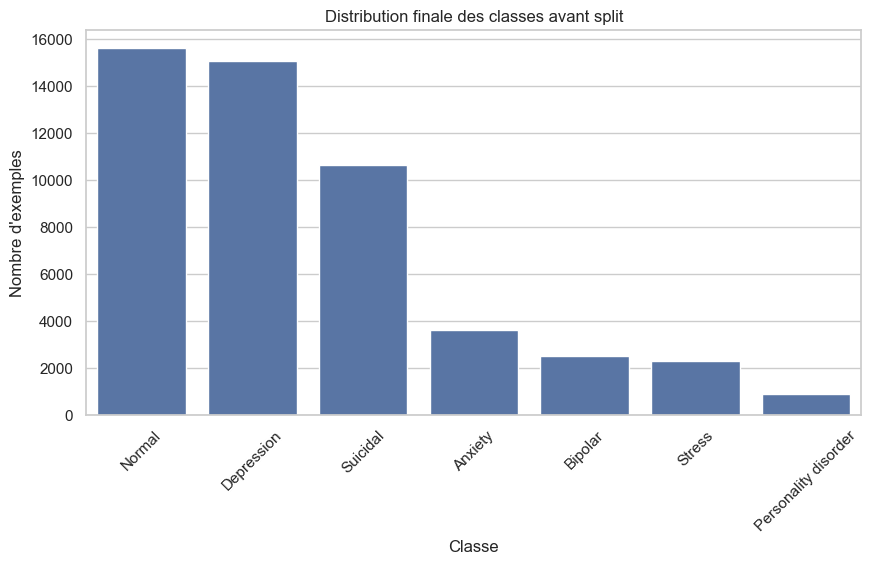

Ratio de déséquilibre : 17.48


In [13]:
TEXT_COL = "clean_text"
LABEL_COL = "status"

required_columns = [TEXT_COL, LABEL_COL]
missing_cols = [col for col in required_columns if col not in df.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes : {missing_cols}")

df_model = df[[TEXT_COL, LABEL_COL]].copy()

df_model[TEXT_COL] = df_model[TEXT_COL].fillna("").astype(str).str.strip()
df_model[LABEL_COL] = df_model[LABEL_COL].astype(str).str.strip()

before = df_model.shape[0]

df_model = df_model[
    (df_model[TEXT_COL] != "") &
    (df_model[LABEL_COL] != "")
].copy()

after = df_model.shape[0]

print("Nombre de lignes avant vérification :", before)
print("Nombre de lignes après vérification :", after)
print("Lignes supprimées :", before - after)

print("\nValeurs manquantes :")
display(df_model.isna().sum())

print("\nDistribution finale des classes :")
class_counts = df_model[LABEL_COL].value_counts()
display(class_counts.to_frame("nombre_exemples"))

plt.figure(figsize=(10, 5))
sns.countplot(data=df_model, x=LABEL_COL, order=class_counts.index)
plt.title("Distribution finale des classes avant split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=45)
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print("Ratio de déséquilibre :", round(imbalance_ratio, 2))

### Interprétation
le ratio de déséquilibre reste élevé, c’est normal : le cleaning ne modifie pas volontairement la distribution naturelle des classes.

La gestion du déséquilibre sera faite pendant l’entraînement avec :
- `class_weight='balanced'` pour Logistic Regression et SVM ;
- poids de classes pour certains modèles ;
- métriques adaptées comme **Macro F1** et **Recall par classe**.

## 4. Séparation X / y

On sépare :
- `X` : les textes nettoyés ;
- `y` : les classes de santé mentale.

Cette séparation permet de préparer la phase d’apprentissage.

In [14]:
X = df_model[TEXT_COL].values
y = df_model[LABEL_COL].values

print("Nombre de textes :", len(X))
print("Nombre de labels :", len(y))
print("Exemple de texte nettoyé :")
print(X[0])
print("\nLabel associé :", y[0])

Nombre de textes : 50606
Nombre de labels : 50606
Exemple de texte nettoyé :
oh gosh

Label associé : Anxiety


## 5. Train / Validation / Test Split

On crée trois ensembles :

- **Train set** : apprentissage des modèles ;
- **Validation set** : comparaison et réglage des modèles ;
- **Test set** : évaluation finale seulement à la fin.

On utilise `stratify=y` pour conserver la même proportion de classes dans chaque ensemble, ce qui est indispensable car le dataset est déséquilibré.

In [16]:
# 70% train, 15% validation, 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train :", len(X_train))
print("Validation :", len(X_val))
print("Test :", len(X_test))

split_summary = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True).sort_index(),
    "validation": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "test": pd.Series(y_test).value_counts(normalize=True).sort_index()
}).round(4) * 100

display(split_summary)

Train : 35424
Validation : 7591
Test : 7591


,train,validation,test
Anxiety,7.10,7.09,7.10
Bipolar,4.94,4.94,4.94
Depression,29.79,29.80,29.80
Normal,30.87,30.88,30.87
Personality disorder,1.77,1.77,1.77
Stress,4.52,4.52,4.53
Suicidal,21.01,21.01,21.00


### Interprétation

Les proportions doivent être proches entre train, validation et test.

Si une classe minoritaire devient trop faible dans le test set, l’évaluation devient instable.  
C’est pour cela que le split stratifié est indispensable dans ce projet.

## 6. Encodage des labels

Les modèles ML travaillent avec des labels numériques.  
On transforme donc les classes textuelles en valeurs numériques avec `LabelEncoder`.

On garde aussi le mapping pour interpréter les résultats.

In [17]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

label_mapping = pd.DataFrame({
    "classe": label_encoder.classes_,
    "encoded_label": range(len(label_encoder.classes_))
})

display(label_mapping)

,classe,encoded_label
0,Anxiety,0
1,Bipolar,1
2,Depression,2
3,Normal,3
4,Personality disorder,4
5,Stress,5
6,Suicidal,6


## 7. Calcul des poids de classes

Le dataset est déséquilibré.  
Pour éviter que les modèles apprennent surtout les classes majoritaires, on calcule des poids de classes.

Ces poids seront utilisés dans les modèles compatibles.

In [18]:
classes_encoded = np.unique(y_train_enc)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes_encoded,
    y=y_train_enc
)

class_weights = dict(zip(classes_encoded, class_weights_values))

class_weights_df = pd.DataFrame({
    "encoded_label": list(class_weights.keys()),
    "class_weight": list(class_weights.values()),
    "classe": label_encoder.inverse_transform(list(class_weights.keys()))
})

display(class_weights_df.sort_values("class_weight", ascending=False))

,encoded_label,class_weight,classe
4,4,8.083980,Personality disorder
5,5,3.158909,Stress
1,1,2.890104,Bipolar
0,0,2.012956,Anxiety
6,6,0.680093,Suicidal
2,2,0.479493,Depression
3,3,0.462744,Normal


### Interprétation

Les classes minoritaires reçoivent un poids plus élevé.  
Cela oblige le modèle à leur accorder plus d’importance pendant l’apprentissage.

Dans ce projet, c’est important parce que rater des classes sensibles comme `Suicidal`, `Depression` ou des classes minoritaires peut avoir un impact fort sur la qualité du modèle.

# Partie A — TF-IDF

## 8. Pourquoi TF-IDF ?

TF-IDF transforme les textes en vecteurs numériques en donnant plus d’importance aux mots spécifiques d’un document et moins aux mots trop fréquents dans tout le corpus.

Dans ce projet, TF-IDF est une baseline très importante parce que :
- il est simple à expliquer ;
- il est rapide ;
- il fonctionne souvent très bien avec SVM et Logistic Regression ;
- il permet d’interpréter les mots importants.

## 9. Analyse rapide d’une vectorisation TF-IDF

Avant d’entraîner les modèles, on crée une première matrice TF-IDF pour comprendre :

- taille du vocabulaire ;
- dimension de la matrice ;
- sparsity ;
- exemples de features.

In [21]:
tfidf_probe = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    token_pattern=r"\b[a-zA-Z']{2,}\b"
)

X_train_tfidf_probe = tfidf_probe.fit_transform(X_train)

print("Shape TF-IDF train :", X_train_tfidf_probe.shape)
print("Taille du vocabulaire :", len(tfidf_probe.get_feature_names_out()))

non_zero = X_train_tfidf_probe.nnz
total_values = X_train_tfidf_probe.shape[0] * X_train_tfidf_probe.shape[1]
density = non_zero / total_values
sparsity = 1 - density

print("Densité :", round(density * 100, 4), "%")
print("Sparsity :", round(sparsity * 100, 4), "%")

print("\nExemples de features :")
print(tfidf_probe.get_feature_names_out()[:50])

Shape TF-IDF train : (35424, 10000)
Taille du vocabulaire : 10000
Densité : 0.4265 %
Sparsity : 99.5735 %

Exemples de features :
["'s" 'aa' 'abandon' 'abandoned' 'abandoning' 'abandonment' 'abdomen'
 'abdominal' 'abdominal pain' 'abilify' 'abilities' 'ability' 'able'
 'able afford' 'able feel' 'able focus' 'able handle' 'able help'
 'able job' 'able just' 'able live' 'able make' 'able not' 'able sleep'
 'able talk' 'able work' 'abnormal' 'abortion' 'about' 'abroad' 'absence'
 'absent' 'absolute' 'absolutely' 'absolutely hate' 'absolutely no'
 'absolutely nothing' 'absurd' 'abt' 'abuse' 'abused' 'abuser' 'abusing'
 'abusive' 'abusive relationship' 'abyss' 'academic' 'academically'
 'academics' 'acc']


### Interprétation TF-IDF

Une matrice TF-IDF est naturellement très sparse : la majorité des mots n’apparaît pas dans chaque document.  
Ce n’est pas un problème en soi, car les modèles linéaires comme Logistic Regression et Linear SVM gèrent bien ce type de données.

la sparsity est très élevée, cela peut justifier plus tard :
- une réduction de `max_features`,
- l’utilisation de `min_df`,
- ou une comparaison avec lemmatization.

## 10. Fonction d’évaluation commune

On crée une fonction unique pour évaluer tous les modèles de la même manière.

On calcule :
- Accuracy ;
- Precision macro ;
- Recall macro ;
- F1 macro ;
- F1 weighted.

La métrique principale recommandée ici est **Macro F1**, car elle donne de l’importance à toutes les classes, même les minoritaires.

In [22]:
def evaluate_model(model_name, vectorizer_name, model, X_eval, y_eval_enc, label_encoder):
    y_pred = model.predict(X_eval)

    accuracy = accuracy_score(y_eval_enc, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_eval_enc, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_eval_enc, y_pred, average="weighted", zero_division=0
    )

    result = {
        "vectorizer": vectorizer_name,
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

    return result, y_pred


def show_classification_report(y_true_enc, y_pred_enc, label_encoder):
    print(classification_report(
        y_true_enc,
        y_pred_enc,
        target_names=label_encoder.classes_,
        zero_division=0
    ))


def plot_confusion(y_true_enc, y_pred_enc, label_encoder, title):
    cm = confusion_matrix(y_true_enc, y_pred_enc)

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(title)
    plt.xlabel("Prédiction")
    plt.ylabel("Vraie classe")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

## 11. Modèles TF-IDF à comparer

On compare plusieurs pipelines :

1. **TF-IDF + Logistic Regression**
2. **TF-IDF + Linear SVM**
3. **TF-IDF + Random Forest**
4. **TF-IDF + XGBoost** si la librairie est disponible

Chaque pipeline contient :
- la vectorisation ;
- le modèle ;
- une petite grille de paramètres.

Le but n’est pas de tester 1000 combinaisons, mais d’avoir une comparaison solide et défendable.

In [23]:
tfidf_pipelines = {}

tfidf_pipelines["TFIDF_LogisticRegression"] = {
    "pipeline": Pipeline([
        ("tfidf", TfidfVectorizer(
            token_pattern=r"\b[a-zA-Z']{2,}\b",
            sublinear_tf=True
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "params": {
        "tfidf__max_features": [5000, 10000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [2],
        "tfidf__max_df": [0.90, 0.95],
        "clf__C": [0.5, 1.0, 2.0]
    }
}

tfidf_pipelines["TFIDF_LinearSVM"] = {
    "pipeline": Pipeline([
        ("tfidf", TfidfVectorizer(
            token_pattern=r"\b[a-zA-Z']{2,}\b",
            sublinear_tf=True
        )),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "params": {
        "tfidf__max_features": [5000, 10000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [2],
        "tfidf__max_df": [0.90, 0.95],
        "clf__C": [0.5, 1.0, 2.0]
    }
}

tfidf_pipelines["TFIDF_RandomForest"] = {
    "pipeline": Pipeline([
        ("tfidf", TfidfVectorizer(
            token_pattern=r"\b[a-zA-Z']{2,}\b",
            sublinear_tf=True
        )),
        ("clf", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "params": {
        "tfidf__max_features": [5000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [2],
        "tfidf__max_df": [0.95],
        "clf__n_estimators": [200],
        "clf__max_depth": [None, 30]
    }
}

# XGBoost optionnel
try:
    from xgboost import XGBClassifier

    tfidf_pipelines["TFIDF_XGBoost"] = {
        "pipeline": Pipeline([
            ("tfidf", TfidfVectorizer(
                token_pattern=r"\b[a-zA-Z']{2,}\b",
                sublinear_tf=True
            )),
            ("clf", XGBClassifier(
                objective="multi:softmax",
                num_class=len(label_encoder.classes_),
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "params": {
            "tfidf__max_features": [5000],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2],
            "tfidf__max_df": [0.95],
            "clf__n_estimators": [200],
            "clf__max_depth": [4, 6],
            "clf__learning_rate": [0.05, 0.1]
        }
    }

    print("XGBoost disponible et ajouté aux modèles.")

except Exception as e:
    print("XGBoost non disponible. Le modèle sera ignoré.")
    print("Erreur :", e)

print("Pipelines disponibles :")
for name in tfidf_pipelines:
    print("-", name)

XGBoost disponible et ajouté aux modèles.
Pipelines disponibles :
- TFIDF_LogisticRegression
- TFIDF_LinearSVM
- TFIDF_RandomForest
- TFIDF_XGBoost


## 12. Entraînement et tuning des modèles TF-IDF

On utilise `GridSearchCV` avec `f1_macro` comme score principal.

Pourquoi `f1_macro` ?
- car le dataset est déséquilibré ;
- car on veut éviter qu’un modèle soit bon uniquement sur les classes majoritaires ;
- car chaque classe doit compter dans l’évaluation.

In [24]:
tfidf_results = []
trained_tfidf_models = {}
tfidf_predictions_val = {}

for name, config in tfidf_pipelines.items():

    print("\n" + "="*80)
    print("Entraînement :", name)
    print("="*80)

    start_time = time.time()

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train_enc)

    elapsed = time.time() - start_time

    print("Meilleurs paramètres :")
    print(grid.best_params_)
    print("Meilleur score CV macro F1 :", round(grid.best_score_, 4))
    print("Temps d'entraînement :", round(elapsed, 2), "secondes")

    best_model = grid.best_estimator_
    result, y_pred_val = evaluate_model(
        model_name=name.replace("TFIDF_", ""),
        vectorizer_name="TF-IDF",
        model=best_model,
        X_eval=X_val,
        y_eval_enc=y_val_enc,
        label_encoder=label_encoder
    )

    result["best_cv_f1_macro"] = grid.best_score_
    result["training_time_sec"] = elapsed
    result["best_params"] = str(grid.best_params_)

    tfidf_results.append(result)
    trained_tfidf_models[name] = best_model
    tfidf_predictions_val[name] = y_pred_val

tfidf_results_df = pd.DataFrame(tfidf_results).sort_values(by="f1_macro", ascending=False)
display(tfidf_results_df)


Entraînement : TFIDF_LogisticRegression
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres :
{'clf__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Meilleur score CV macro F1 : 0.685
Temps d'entraînement : 172.64 secondes

Entraînement : TFIDF_LinearSVM
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres :
{'clf__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Meilleur score CV macro F1 : 0.6776
Temps d'entraînement : 153.38 secondes

Entraînement : TFIDF_RandomForest
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Meilleurs paramètres :
{'clf__max_depth': 30, 'clf__n_estimators': 200, 'tfidf__max_df': 0.95, 'tfidf__max_features': 5000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Meilleur score CV macro F1 : 0.6272
Temps d'entraînement : 386.7 secondes

Entraînement : TFIDF_XGBoost
F

,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,best_cv_f1_macro,training_time_sec,best_params
0,TF-IDF,LogisticRegression,0.736003,0.659678,0.707854,0.679310,0.743014,0.736003,0.736375,0.685027,172.639827,"{'clf__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__..."
1,TF-IDF,LinearSVM,0.741009,0.670818,0.687349,0.678035,0.739383,0.741009,0.738761,0.677647,153.381882,"{'clf__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__..."
3,TF-IDF,XGBoost,0.743117,0.754668,0.627106,0.669416,0.740766,0.743117,0.735779,0.671880,1730.821805,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
2,TF-IDF,RandomForest,0.702016,0.708354,0.598058,0.627715,0.700010,0.702016,0.693985,0.627248,386.703289,"{'clf__max_depth': 30, 'clf__n_estimators': 20..."


In [25]:
# =========================
# TABLEAU COMPARATIF DES MODÈLES TF-IDF
# =========================

tfidf_comparison = tfidf_results_df.copy()

cols_to_show = [
    "vectorizer",
    "model",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "best_cv_f1_macro",
    "training_time_sec",
    "best_params"
]

tfidf_comparison = tfidf_comparison[cols_to_show]

tfidf_comparison["training_time_sec"] = tfidf_comparison["training_time_sec"].round(2)
tfidf_comparison["accuracy"] = tfidf_comparison["accuracy"].round(4)
tfidf_comparison["precision_macro"] = tfidf_comparison["precision_macro"].round(4)
tfidf_comparison["recall_macro"] = tfidf_comparison["recall_macro"].round(4)
tfidf_comparison["f1_macro"] = tfidf_comparison["f1_macro"].round(4)
tfidf_comparison["best_cv_f1_macro"] = tfidf_comparison["best_cv_f1_macro"].round(4)

display(tfidf_comparison)

,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,best_cv_f1_macro,training_time_sec,best_params
0,TF-IDF,LogisticRegression,0.7360,0.6597,0.7079,0.6793,0.6850,172.64,"{'clf__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__..."
1,TF-IDF,LinearSVM,0.7410,0.6708,0.6873,0.6780,0.6776,153.38,"{'clf__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__..."
3,TF-IDF,XGBoost,0.7431,0.7547,0.6271,0.6694,0.6719,1730.82,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
2,TF-IDF,RandomForest,0.7020,0.7084,0.5981,0.6277,0.6272,386.70,"{'clf__max_depth': 30, 'clf__n_estimators': 20..."


## 13. Analyse du meilleur modèle TF-IDF sur validation

On sélectionne le meilleur modèle TF-IDF selon le **Macro F1** sur le validation set.

Ensuite, on affiche :
- classification report ;
- matrice de confusion ;
- interprétation des classes bien ou mal reconnues.

Meilleur modèle TF-IDF : TFIDF_LogisticRegression
Macro F1 validation : 0.6793

Classification report :
                      precision    recall  f1-score   support

             Anxiety       0.74      0.81      0.78       538
             Bipolar       0.72      0.76      0.74       375
          Depression       0.75      0.61      0.67      2262
              Normal       0.88      0.91      0.89      2344
Personality disorder       0.46      0.60      0.52       134
              Stress       0.44      0.59      0.50       343
            Suicidal       0.63      0.68      0.65      1595

            accuracy                           0.74      7591
           macro avg       0.66      0.71      0.68      7591
        weighted avg       0.74      0.74      0.74      7591



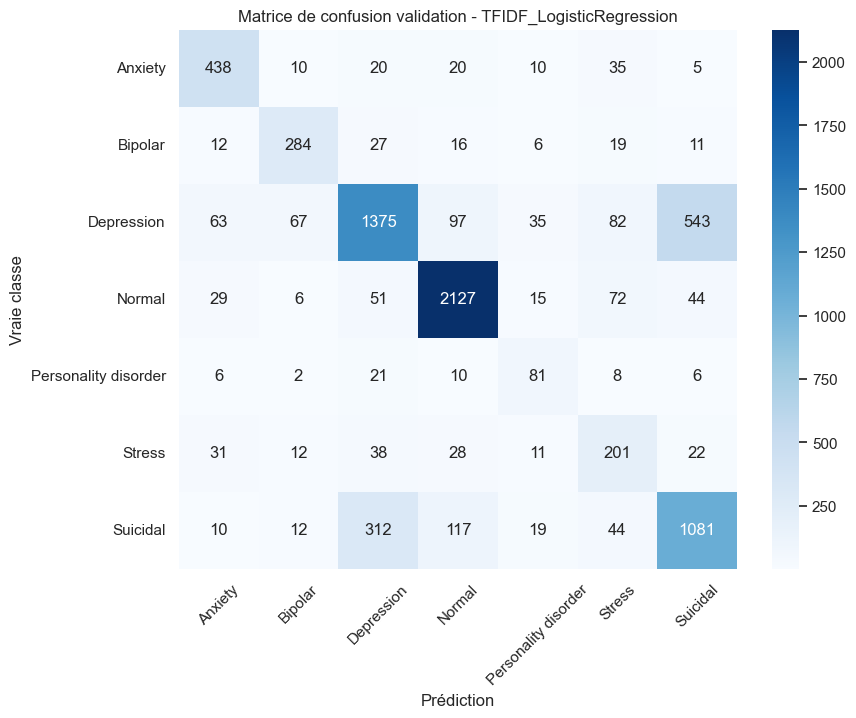

In [27]:
best_tfidf_row = tfidf_results_df.iloc[0]
best_tfidf_key = "TFIDF_" + best_tfidf_row["model"]

best_tfidf_model = trained_tfidf_models[best_tfidf_key]
best_tfidf_pred_val = tfidf_predictions_val[best_tfidf_key]

print("Meilleur modèle TF-IDF :", best_tfidf_key)
print("Macro F1 validation :", round(best_tfidf_row["f1_macro"], 4))
print("\nClassification report :")
show_classification_report(y_val_enc, best_tfidf_pred_val, label_encoder)

plot_confusion(
    y_val_enc,
    best_tfidf_pred_val,
    label_encoder,
    title=f"Matrice de confusion validation - {best_tfidf_key}"
)

## 14. Analyse des features importantes du meilleur modèle TF-IDF

Cette partie est possible surtout pour les modèles linéaires :
- Logistic Regression ;
- Linear SVM.

Elle permet de voir quels mots ou expressions influencent chaque classe.

C’est très utile pour l’interprétabilité du projet.

In [29]:
def show_top_features_linear_model(pipeline, label_encoder, top_n=15):
    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    feature_names = np.array(vectorizer.get_feature_names_out())

    if not hasattr(clf, "coef_"):
        print("Ce modèle ne possède pas de coefficients linéaires interprétables.")
        return

    coefs = clf.coef_

    for i, class_name in enumerate(label_encoder.classes_):
        print("\n" + "="*60)
        print("Classe :", class_name)
        print("="*60)

        top_idx = np.argsort(coefs[i])[-top_n:][::-1]
        top_features = pd.DataFrame({
            "feature": feature_names[top_idx],
            "coefficient": coefs[i][top_idx]
        })

        display(top_features)

show_top_features_linear_model(best_tfidf_model, label_encoder, top_n=15)


Classe : Anxiety


,feature,coefficient
0,anxiety,12.343230
1,restless,10.577488
2,anxious,8.117008
3,worried,7.611536
4,nervous,7.126551
5,worry,5.523771
6,cancer,5.359714
7,restlessness,4.410209
8,freaking,4.240218
9,health anxiety,4.115727



Classe : Bipolar


,feature,coefficient
0,bipolar,17.264317
1,manic,11.664009
2,meds,8.034867
3,mania,7.772506
4,lithium,7.077822
5,hypomanic,6.975631
6,lamictal,6.880238
7,episode,6.790728
8,latuda,6.444837
9,bp,6.417941



Classe : Depression


...

,feature,coefficient
0,avpd,18.337081
1,avoidant,6.223190
2,there's,5.352645
3,interaction,5.033768
4,avoiding,4.837468
5,disorder,4.767888
6,poll,4.733403
7,people,4.558045
8,social,4.544934
9,view poll,4.490101



Classe : Stress


,feature,coefficient
0,stress,11.472093
1,stressed,7.577159
2,ptsd,7.189021
3,tl dr,4.522867
4,abuse,4.082365
5,boyfriend,4.064818
6,happened,3.970285
7,anxiety,3.847972
8,dr,3.598744
9,tl,3.565733



Classe : Suicidal


,feature,coefficient
0,suicidal,7.879149
1,suicide,7.553588
2,kill,7.075337
3,die,6.141803
4,rt,4.390171
5,goodbye,4.060720
6,fucking,3.761339
7,overdose,3.746234
8,killing,3.589241
9,pills,3.560675


# Partie B — Word2Vec

## 15. Pourquoi Word2Vec ?

TF-IDF représente les textes par fréquence de mots.  
Word2Vec apprend des vecteurs denses où les mots proches dans le contexte ont des représentations proches.

Dans ce projet, Word2Vec permet de tester une représentation plus sémantique, mais toujours classique et explicable.

## 16. Préparation des tokens pour Word2Vec

Word2Vec travaille sur des listes de tokens.

Important :
- le modèle Word2Vec doit être entraîné uniquement sur le train set ;
- puis on transforme validation et test avec le même espace vectoriel.

In [30]:
def simple_tokenize(text):
    return re.findall(r"\b[a-zA-Z']{2,}\b", str(text).lower())

train_tokens = [simple_tokenize(text) for text in X_train]
val_tokens = [simple_tokenize(text) for text in X_val]
test_tokens = [simple_tokenize(text) for text in X_test]

print("Exemple de tokens :")
print(train_tokens[0][:30])

token_lengths = [len(tokens) for tokens in train_tokens]
print("\nLongueur moyenne en tokens train :", round(np.mean(token_lengths), 2))

Exemple de tokens :
['talk', 'need', 'help', 'hahahhahhahahahahhahahahaha', 'hahahahahahahahahahweahaehahahahahahaan', 'ha', 'han', 'saghah', 'talk', 'need', 'help']

Longueur moyenne en tokens train : 47.17


## 17. Entraînement Word2Vec

On entraîne Word2Vec sur le train set.

Paramètres importants :
- `vector_size` : dimension du vecteur ;
- `window` : taille du contexte ;
- `min_count` : fréquence minimale d’un mot ;
- `sg=1` : Skip-gram ;
- `sg=0` : CBOW.

Pour commencer, on teste une configuration raisonnable.

In [31]:
try:
    from gensim.models import Word2Vec

    w2v_model = Word2Vec(
        sentences=train_tokens,
        vector_size=100,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=10,
        seed=RANDOM_STATE
    )

    print("Word2Vec entraîné avec succès.")
    print("Taille du vocabulaire Word2Vec :", len(w2v_model.wv.index_to_key))

except Exception as e:
    w2v_model = None
    print("Impossible d'entraîner Word2Vec.")
    print("Installez gensim avec : pip install gensim")
    print("Erreur :", e)

Word2Vec entraîné avec succès.
Taille du vocabulaire Word2Vec : 23165


## 18. Transformation des textes en vecteurs Word2Vec

Pour représenter un texte complet, on calcule la moyenne des vecteurs de ses mots.

C’est une méthode simple, mais très utile comme baseline Word2Vec.

In [32]:
def document_vector(tokens, model, vector_size=100):
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)


if w2v_model is not None:
    X_train_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in train_tokens])
    X_val_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in val_tokens])
    X_test_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in test_tokens])

    print("Shape Word2Vec train :", X_train_w2v.shape)
    print("Shape Word2Vec validation :", X_val_w2v.shape)
    print("Shape Word2Vec test :", X_test_w2v.shape)
else:
    print("Word2Vec non disponible.")

Shape Word2Vec train : (35424, 100)
Shape Word2Vec validation : (7591, 100)
Shape Word2Vec test : (7591, 100)


## 19. Modèles sur Word2Vec

On compare les mêmes familles de modèles :

- Logistic Regression ;
- Linear SVM ;
- Random Forest ;
- XGBoost si disponible.

Ici les vecteurs sont denses, donc Random Forest et XGBoost peuvent parfois mieux se comporter que sur TF-IDF sparse.

In [33]:
w2v_models = {}

if w2v_model is not None:

    w2v_models["W2V_LogisticRegression"] = {
        "model": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "C": [0.5, 1.0, 2.0]
        }
    }

    w2v_models["W2V_LinearSVM"] = {
        "model": LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "params": {
            "C": [0.5, 1.0, 2.0]
        }
    }

    w2v_models["W2V_RandomForest"] = {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [200, 300],
            "max_depth": [None, 30]
        }
    }

    try:
        from xgboost import XGBClassifier

        w2v_models["W2V_XGBoost"] = {
            "model": XGBClassifier(
                objective="multi:softmax",
                num_class=len(label_encoder.classes_),
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            "params": {
                "n_estimators": [200],
                "max_depth": [4, 6],
                "learning_rate": [0.05, 0.1]
            }
        }

    except Exception:
        pass

    print("Modèles Word2Vec disponibles :")
    for name in w2v_models:
        print("-", name)
else:
    print("Aucun modèle Word2Vec disponible.")

Modèles Word2Vec disponibles :
- W2V_LogisticRegression
- W2V_LinearSVM
- W2V_RandomForest
- W2V_XGBoost


## 20. Entraînement des modèles Word2Vec

On utilise encore `GridSearchCV` avec `f1_macro`.

Comme les matrices Word2Vec sont denses et plus petites, l’entraînement est souvent plus simple.

In [34]:
w2v_results = []
trained_w2v_models = {}
w2v_predictions_val = {}

if w2v_model is not None:

    for name, config in w2v_models.items():

        print("\n" + "="*80)
        print("Entraînement :", name)
        print("="*80)

        start_time = time.time()

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring="f1_macro",
            cv=3,
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train_w2v, y_train_enc)

        elapsed = time.time() - start_time

        print("Meilleurs paramètres :")
        print(grid.best_params_)
        print("Meilleur score CV macro F1 :", round(grid.best_score_, 4))
        print("Temps d'entraînement :", round(elapsed, 2), "secondes")

        best_model = grid.best_estimator_

        result, y_pred_val = evaluate_model(
            model_name=name.replace("W2V_", ""),
            vectorizer_name="Word2Vec",
            model=best_model,
            X_eval=X_val_w2v,
            y_eval_enc=y_val_enc,
            label_encoder=label_encoder
        )

        result["best_cv_f1_macro"] = grid.best_score_
        result["training_time_sec"] = elapsed
        result["best_params"] = str(grid.best_params_)

        w2v_results.append(result)
        trained_w2v_models[name] = best_model
        w2v_predictions_val[name] = y_pred_val

    w2v_results_df = pd.DataFrame(w2v_results).sort_values(by="f1_macro", ascending=False)
    display(w2v_results_df)

else:
    w2v_results_df = pd.DataFrame()
    print("Word2Vec n'a pas été exécuté.")


Entraînement : W2V_LogisticRegression
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Meilleurs paramètres :
{'C': 2.0}
Meilleur score CV macro F1 : 0.5368
Temps d'entraînement : 17.63 secondes

Entraînement : W2V_LinearSVM
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Meilleurs paramètres :
{'C': 2.0}
Meilleur score CV macro F1 : 0.5537
Temps d'entraînement : 22.84 secondes

Entraînement : W2V_RandomForest
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Meilleurs paramètres :
{'max_depth': 30, 'n_estimators': 200}
Meilleur score CV macro F1 : 0.5141
Temps d'entraînement : 413.68 secondes

Entraînement : W2V_XGBoost
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Meilleurs paramètres :
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Meilleur score CV macro F1 : 0.6145
Temps d'entraînement : 300.48 secondes


,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,best_cv_f1_macro,training_time_sec,best_params
3,Word2Vec,XGBoost,0.723225,0.709209,0.588135,0.625854,0.723041,0.723225,0.717654,0.614531,300.476375,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
1,Word2Vec,LinearSVM,0.628244,0.529674,0.633499,0.556710,0.661970,0.628244,0.636067,0.553660,22.842795,{'C': 2.0}
0,Word2Vec,LogisticRegression,0.595837,0.518345,0.641533,0.534685,0.675809,0.595837,0.615533,0.536776,17.629320,{'C': 2.0}
2,Word2Vec,RandomForest,0.683573,0.710674,0.486821,0.519859,0.701378,0.683573,0.665247,0.514121,413.677984,"{'max_depth': 30, 'n_estimators': 200}"


# Partie C — Comparaison globale

## 21. Comparaison TF-IDF vs Word2Vec

On regroupe tous les résultats validation dans un seul tableau.

Le meilleur modèle sera choisi principalement selon :
- Macro F1 ;
- Recall macro ;
- stabilité ;
- interprétabilité ;
- temps d’entraînement.

,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,best_cv_f1_macro,training_time_sec,best_params
0,TF-IDF,LogisticRegression,0.736003,0.659678,0.707854,0.679310,0.743014,0.736003,0.736375,0.685027,172.639827,"{'clf__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__..."
1,TF-IDF,LinearSVM,0.741009,0.670818,0.687349,0.678035,0.739383,0.741009,0.738761,0.677647,153.381882,"{'clf__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__..."
2,TF-IDF,XGBoost,0.743117,0.754668,0.627106,0.669416,0.740766,0.743117,0.735779,0.671880,1730.821805,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
3,TF-IDF,RandomForest,0.702016,0.708354,0.598058,0.627715,0.700010,0.702016,0.693985,0.627248,386.703289,"{'clf__max_depth': 30, 'clf__n_estimators': 20..."
4,Word2Vec,XGBoost,0.723225,0.709209,0.588135,0.625854,0.723041,0.723225,0.717654,0.614531,300.476375,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
5,Word2Vec,LinearSVM,0.628244,0.529674,0.633499,0.556710,0.661970,0.628244,0.636067,0.553660,22.842795,{'C': 2.0}
6,Word2Vec,LogisticRegression,0.595837,0.518345,0.641533,0.534685,0.675809,0.595837,0.615533,0.536776,17.629320,{'C': 2.0}
7,Word2Vec,RandomForest,0.683573,0.710674,0.486821,0.519859,0.701378,0.683573,0.665247,0.514121,413.677984,"{'max_depth': 30, 'n_estimators': 200}"


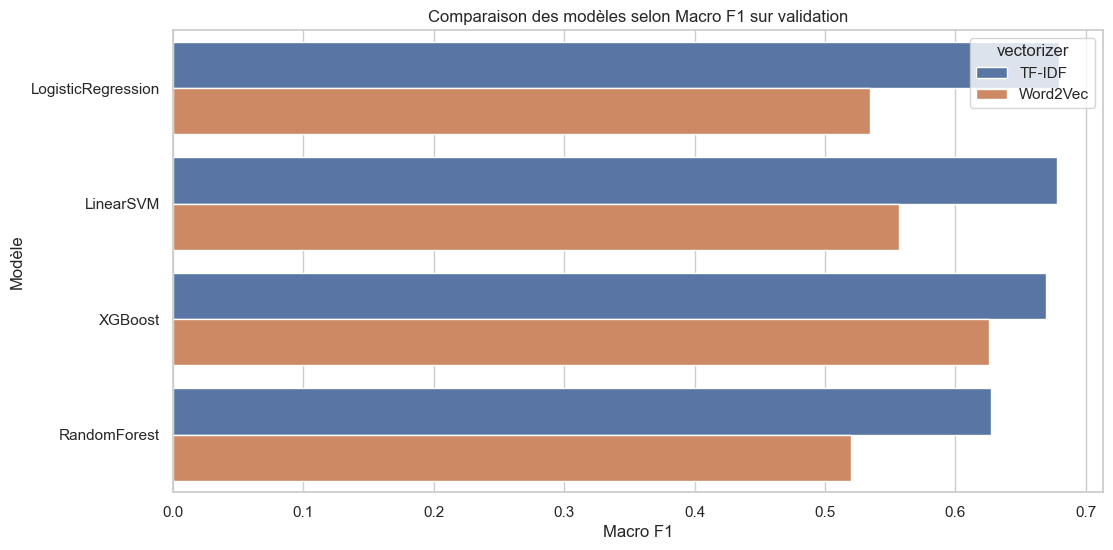

In [36]:
all_results_df = pd.concat(
    [tfidf_results_df, w2v_results_df],
    ignore_index=True
).sort_values(by="f1_macro", ascending=False)

display(all_results_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df, x="f1_macro", y="model", hue="vectorizer")
plt.title("Comparaison des modèles selon Macro F1 sur validation")
plt.xlabel("Macro F1")
plt.ylabel("Modèle")
plt.show()

### Interprétation attendue

Si TF-IDF + Linear SVM ou TF-IDF + Logistic Regression arrive en tête, c’est un résultat très cohérent en classification de texte classique.

Si Word2Vec est moins performant, ce n’est pas forcément un échec :
- TF-IDF capture directement les mots discriminants ;
- Word2Vec moyenne les vecteurs et peut perdre certains signaux précis ;
- les bigrams TF-IDF peuvent mieux capturer des expressions comme `not okay`, `kill myself`, `feel empty`.

## 22. Sélection automatique du meilleur modèle validation

On choisit le modèle avec le meilleur Macro F1 validation.

Attention : le test set n’est pas encore utilisé pour choisir le modèle.  
Il sert seulement à l’évaluation finale.

In [37]:
best_row = all_results_df.iloc[0]

print("Meilleur modèle sur validation :")
display(best_row.to_frame().T)

best_vectorizer = best_row["vectorizer"]
best_model_name = best_row["model"]

if best_vectorizer == "TF-IDF":
    best_key = "TFIDF_" + best_model_name
    best_model = trained_tfidf_models[best_key]
    best_X_test = X_test
    best_X_val = X_val
    best_pred_val = tfidf_predictions_val[best_key]

elif best_vectorizer == "Word2Vec":
    best_key = "W2V_" + best_model_name
    best_model = trained_w2v_models[best_key]
    best_X_test = X_test_w2v
    best_X_val = X_val_w2v
    best_pred_val = w2v_predictions_val[best_key]

print("Clé du meilleur modèle :", best_key)

Meilleur modèle sur validation :


,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,best_cv_f1_macro,training_time_sec,best_params
0,TF-IDF,LogisticRegression,0.736003,0.659678,0.707854,0.67931,0.743014,0.736003,0.736375,0.685027,172.639827,"{'clf__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__..."


Clé du meilleur modèle : TFIDF_LogisticRegression


## 23. Évaluation finale sur le test set

Maintenant seulement, on évalue le meilleur modèle sur le test set.

Cette étape donne la performance finale réaliste.

Résultats finaux sur test set :


,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,TF-IDF,LogisticRegression,0.746147,0.681987,0.720769,0.697336,0.753815,0.746147,0.746878



Classification report test :
                      precision    recall  f1-score   support

             Anxiety       0.76      0.83      0.79       539
             Bipolar       0.73      0.75      0.74       375
          Depression       0.76      0.63      0.69      2262
              Normal       0.88      0.91      0.90      2343
Personality disorder       0.57      0.63      0.60       134
              Stress       0.42      0.62      0.50       344
            Suicidal       0.64      0.68      0.66      1594

            accuracy                           0.75      7591
           macro avg       0.68      0.72      0.70      7591
        weighted avg       0.75      0.75      0.75      7591



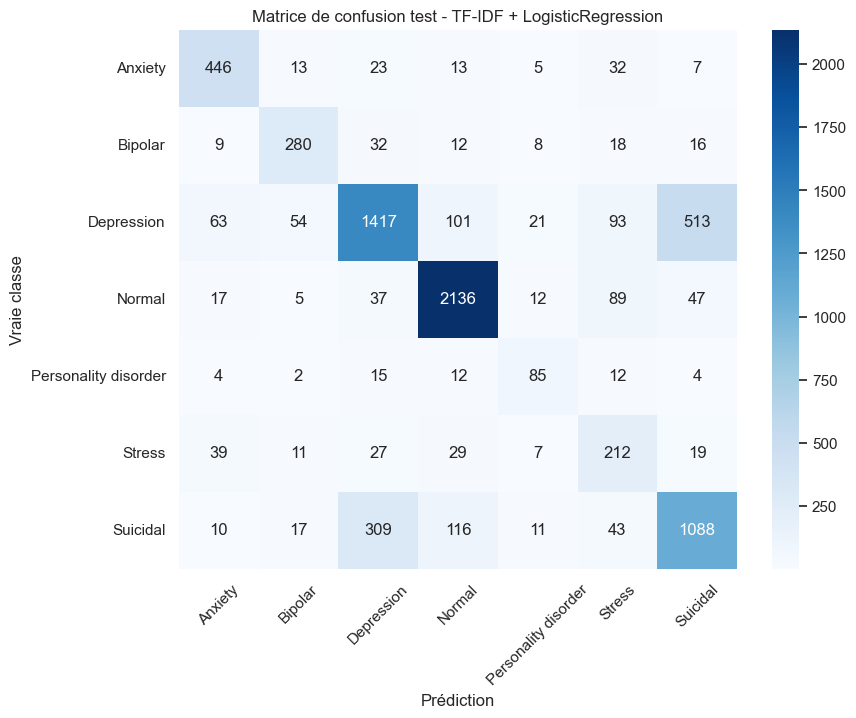

In [38]:
test_result, y_pred_test = evaluate_model(
    model_name=best_model_name,
    vectorizer_name=best_vectorizer,
    model=best_model,
    X_eval=best_X_test,
    y_eval_enc=y_test_enc,
    label_encoder=label_encoder
)

print("Résultats finaux sur test set :")
display(pd.DataFrame([test_result]))

print("\nClassification report test :")
show_classification_report(y_test_enc, y_pred_test, label_encoder)

plot_confusion(
    y_test_enc,
    y_pred_test,
    label_encoder,
    title=f"Matrice de confusion test - {best_vectorizer} + {best_model_name}"
)

## 24. Analyse des erreurs

On affiche quelques exemples mal classés.

Cette analyse est très importante pour comprendre :
- les classes confondues ;
- les textes ambigus ;
- les limites du modèle ;
- les prochaines améliorations possibles.

In [39]:
error_df = pd.DataFrame({
    "text": X_test,
    "true_label": label_encoder.inverse_transform(y_test_enc),
    "predicted_label": label_encoder.inverse_transform(y_pred_test)
})

error_df = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()

print("Nombre d'erreurs sur le test set :", len(error_df))
display(error_df.head(20))

Nombre d'erreurs sur le test set : 1927


,text,true_label,predicted_label
6,know post wanted write hopefully chest life ju...,Depression,Suicidal
9,went va help called veteran crisis hotline no ...,Depression,Suicidal
17,april started new job 1st time years good job ...,Depression,Bipolar
22,does zoloft help? used zoloft 5 days month ago...,Personality disorder,Anxiety
32,im currently taking psych med zoloft buspar li...,Depression,Bipolar
39,typically dish jokes things friends recently f...,Depression,Stress
40,everythingi just know willeverything's going b...,Depression,Normal
44,family damn beautiful start ugly generation ju...,Suicidal,Depression
45,tired want die reason not die? say sensible no...,Anxiety,Suicidal
50,19 year old man spent life severe anxiety ment...,Depression,Suicidal


## 25. Analyse des confusions principales

On identifie les paires de classes les plus souvent confondues.

Exemple possible :
- Depression confondue avec Suicidal ;
- Anxiety confondue avec Stress ;
- Bipolar confondu avec Depression.

Cela aide à expliquer les limites du modèle dans le rapport.

,true_label,predicted_label,count
17,Depression,Suicidal,513
38,Suicidal,Depression,309
39,Suicidal,Normal,116
14,Depression,Normal,101
16,Depression,Stress,93
22,Normal,Stress,89
12,Depression,Anxiety,63
13,Depression,Bipolar,54
23,Normal,Suicidal,47
41,Suicidal,Stress,43


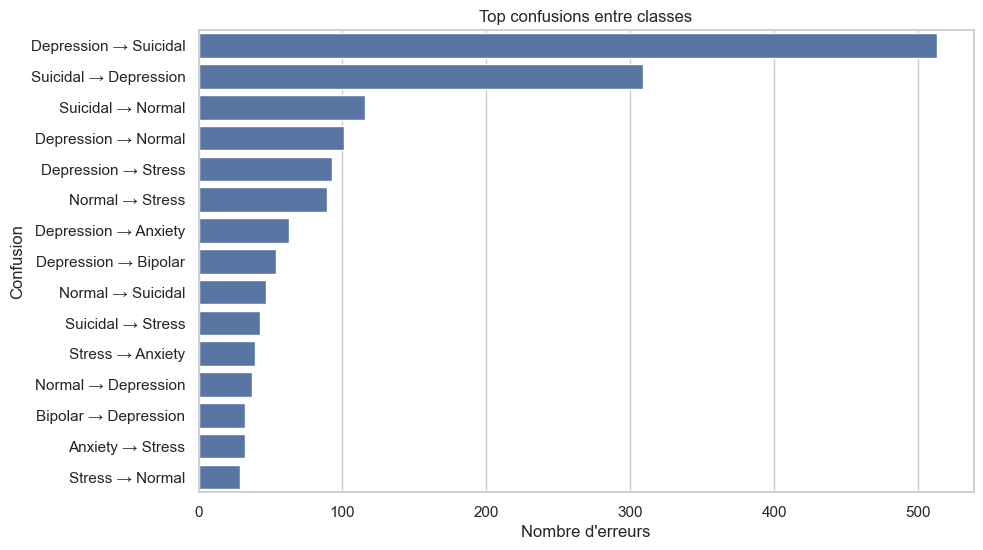

In [40]:
confusion_pairs = error_df.groupby(
    ["true_label", "predicted_label"]
).size().reset_index(name="count").sort_values(by="count", ascending=False)

display(confusion_pairs.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=confusion_pairs.head(15),
    x="count",
    y=confusion_pairs.head(15).apply(lambda row: f"{row['true_label']} → {row['predicted_label']}", axis=1)
)
plt.title("Top confusions entre classes")
plt.xlabel("Nombre d'erreurs")
plt.ylabel("Confusion")
plt.show()

## 26. Sauvegarde du meilleur modèle

On sauvegarde :
- le meilleur modèle ;
- le label encoder ;
- le tableau des résultats ;
- les prédictions d’erreur.

Cela permet de réutiliser le modèle plus tard dans un dashboard ou une application.

In [41]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

joblib.dump(best_model, "models/best_model_step03.joblib")
joblib.dump(label_encoder, "models/label_encoder_step03.joblib")

all_results_df.to_csv("outputs/model_comparison_step03.csv", index=False)
error_df.to_csv("outputs/test_errors_step03.csv", index=False)

print("Modèle sauvegardé dans : models/best_model_step03.joblib")
print("Label encoder sauvegardé dans : models/label_encoder_step03.joblib")
print("Résultats sauvegardés dans : outputs/model_comparison_step03.csv")
print("Erreurs sauvegardées dans : outputs/test_errors_step03.csv")

if best_vectorizer == "Word2Vec" and w2v_model is not None:
    w2v_model.save("models/word2vec_model_step03.model")
    print("Word2Vec sauvegardé dans : models/word2vec_model_step03.model")

Modèle sauvegardé dans : models/best_model_step03.joblib
Label encoder sauvegardé dans : models/label_encoder_step03.joblib
Résultats sauvegardés dans : outputs/model_comparison_step03.csv
Erreurs sauvegardées dans : outputs/test_errors_step03.csv


## 27. Synthèse automatique de l’étape 03

Cette synthèse peut être réutilisée dans le rapport.

In [42]:
summary = []

summary.append("Le dataset nettoyé issu du Step 02 a été utilisé pour la modélisation.")
summary.append("Un split stratifié Train / Validation / Test a été appliqué afin de conserver la distribution des classes.")
summary.append("Les labels textuels ont été encodés numériquement avec LabelEncoder.")
summary.append("Le déséquilibre des classes a été pris en compte avec des poids de classes pour les modèles compatibles.")
summary.append("La représentation TF-IDF a été testée avec plusieurs configurations de n-grams et de taille de vocabulaire.")
summary.append("Des modèles classiques ont été comparés : Logistic Regression, Linear SVM, Random Forest et XGBoost si disponible.")
summary.append("Word2Vec a également été testé comme représentation dense et sémantique.")
summary.append(f"Le meilleur modèle sur validation est : {best_vectorizer} + {best_model_name}.")
summary.append(f"Son Macro F1 sur validation est : {round(best_row['f1_macro'], 4)}.")
summary.append(f"Son Macro F1 final sur test est : {round(test_result['f1_macro'], 4)}.")
summary.append("Les erreurs de classification ont été analysées pour identifier les classes les plus confondues.")

print("SYNTHÈSE STEP 03")
print("="*60)

for item in summary:
    print("- " + item)

SYNTHÈSE STEP 03
- Le dataset nettoyé issu du Step 02 a été utilisé pour la modélisation.
- Un split stratifié Train / Validation / Test a été appliqué afin de conserver la distribution des classes.
- Les labels textuels ont été encodés numériquement avec LabelEncoder.
- Le déséquilibre des classes a été pris en compte avec des poids de classes pour les modèles compatibles.
- La représentation TF-IDF a été testée avec plusieurs configurations de n-grams et de taille de vocabulaire.
- Des modèles classiques ont été comparés : Logistic Regression, Linear SVM, Random Forest et XGBoost si disponible.
- Word2Vec a également été testé comme représentation dense et sémantique.
- Le meilleur modèle sur validation est : TF-IDF + LogisticRegression.
- Son Macro F1 sur validation est : 0.6793.
- Son Macro F1 final sur test est : 0.6973.
- Les erreurs de classification ont été analysées pour identifier les classes les plus confondues.


# Conclusion de l’étape 03

r :

- une comparaison claire entre TF-IDF et Word2Vec ;
- plusieurs modèles classiques entraînés ;
- une sélection justifiée du meilleur modèle ;
- une évaluation finale sur test set ;
- une analyse des erreurs ;
- un modèle sauvegardé pour la suite.

La prochaine étape logique sera :

```text
Step 04 — Model Optimization & Deployment Preparation
```

Mais avant cela, il faut analyser calmement les résultats obtenus dans ce notebook.